# Assignment 2 - Anomaly Detection using Deep Learning

Petter Eriksson  
Deep Machine Learning

## 1. Imports and Reproducibility

A fixed seed is used to make the experiment as reproducible as possible. Some GPU operations can still show very small numerical differences between systems.

In [1]:
import os
import ast
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True)
except Exception as e:
    print("Deterministic algorithms not fully available:", e)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Seed set to:", SEED)
print("Using device:", device)

Seed set to: 42
Using device: cuda


# Load and Inspect the Dataset

First, download and inspect the dataset structure.

## Dataset

NASA SMAP/MSL telemetry dataset downloaded from Kaggle:

https://www.kaggle.com/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl

In [ ]:
#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("patrickfleith/nasa-anomaly-detection-dataset-smap-msl")

#print("Path to dataset files:", path)

#### Inspect Dataset


The selected channel is `A-1`. It contains multivariate telemetry data with 25 features per timestep.

In [2]:
path = r"C:\Users\pette\.cache\kagglehub\datasets\patrickfleith\nasa-anomaly-detection-dataset-smap-msl\versions\1"

channel_id = "A-1"

# The Kaggle dataset has a nested folder structure: data/data/train and data/data/test
train_path = os.path.join(path, "data", "data", "train", f"{channel_id}.npy")
test_path = os.path.join(path, "data", "data", "test", f"{channel_id}.npy")
labels_path = os.path.join(path, "labeled_anomalies.csv")

train = np.load(train_path)
test = np.load(test_path)
labels_df = pd.read_csv(labels_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("First rows:")
print(train[:5])
print(labels_df.head())

Train shape: (2880, 25)
Test shape: (8640, 25)
First rows:
[[0.999 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [0.999 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [0.999 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [0.999 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]
 [0.999 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.   ]]
  chan_id spacecraft                           anomaly_sequences  \
0     P-1       SMAP  [[2149, 2349], [4536, 4844], [3539, 3779]]   
1     S-1       SMAP                             

# Normalize the Data

The telemetry channel contains 25 features. The training data is used to fit the scaler, and the same scaler is applied to the test data to avoid data leakage.

In [3]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

print("Scaled train shape:", train_scaled.shape)
print("Scaled test shape:", test_scaled.shape)
print("Train mean after scaling:", train_scaled.mean())
print("Train std after scaling:", train_scaled.std())

Scaled train shape: (2880, 25)
Scaled test shape: (8640, 25)
Train mean after scaling: 1.7680671741497159e-15
Train std after scaling: 0.8485281374238507


### Create LSTM Sequences

The normalized time series is converted into overlapping windows so that the LSTM can learn temporal patterns.

In [4]:
def create_sequences(data, window_size=50):
    sequences = []

    for i in range(len(data) - window_size):
        sequences.append(data[i:i + window_size])

    return np.array(sequences)

window_size = 50

X_train = create_sequences(train_scaled, window_size)
X_test = create_sequences(test_scaled, window_size)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (2830, 50, 25)
X_test shape: (8590, 50, 25)


# Convert Data to PyTorch Tensors

The LSTM autoencoder will be trained using PyTorch, so the NumPy arrays are converted into tensors.
Since this is an autoencoder, the target output is the same as the input.

In [5]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
test_dataset = TensorDataset(X_test_tensor, X_test_tensor)

batch_size = 64

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=generator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

input_size = X_train.shape[2]

print("Input size:", input_size)
print("Train tensor shape:", X_train_tensor.shape)
print("Test tensor shape:", X_test_tensor.shape)

Input size: 25
Train tensor shape: torch.Size([2830, 50, 25])
Test tensor shape: torch.Size([8590, 50, 25])


###  LSTM Autoencoder Model 1

The first model is a simple LSTM autoencoder with one encoder LSTM and one decoder LSTM.
It learns to reconstruct normal telemetry sequences.

In [6]:
class LSTMAutoencoder1(nn.Module):
    def __init__(self, input_size, hidden_size=64, latent_size=32):
        super(LSTMAutoencoder1, self).__init__()

        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.latent = nn.Linear(hidden_size, latent_size)
        self.expand = nn.Linear(latent_size, hidden_size)

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        _, (hidden, _) = self.encoder(x)
        z = self.latent(hidden[-1])
        z = self.expand(z)
        decoder_input = z.unsqueeze(1).repeat(1, seq_len, 1)
        decoded, _ = self.decoder(decoder_input)
        output = self.output_layer(decoded)
        return output

model1 = LSTMAutoencoder1(input_size=input_size, hidden_size=64, latent_size=32).to(device)
print(model1)

LSTMAutoencoder1(
  (encoder): LSTM(25, 64, batch_first=True)
  (latent): Linear(in_features=64, out_features=32, bias=True)
  (expand): Linear(in_features=32, out_features=64, bias=True)
  (decoder): LSTM(64, 64, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=25, bias=True)
)


###  LSTM Autoencoder Model 2




In [7]:
class LSTMAutoencoder2(nn.Module):
    def __init__(self, input_size, hidden_size=128, latent_size=64, num_layers=2, dropout=0.2):
        super(LSTMAutoencoder2, self).__init__()

        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.latent = nn.Linear(hidden_size, latent_size)
        self.expand = nn.Linear(latent_size, hidden_size)

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        _, (hidden, _) = self.encoder(x)
        z = self.latent(hidden[-1])
        z = self.expand(z)
        decoder_input = z.unsqueeze(1).repeat(1, seq_len, 1)
        decoded, _ = self.decoder(decoder_input)
        output = self.output_layer(decoded)
        return output

model2 = LSTMAutoencoder2(
    input_size=input_size,
    hidden_size=128,
    latent_size=64,
    num_layers=2,
    dropout=0.2
).to(device)

print(model2)

LSTMAutoencoder2(
  (encoder): LSTM(25, 128, num_layers=2, batch_first=True, dropout=0.2)
  (latent): Linear(in_features=128, out_features=64, bias=True)
  (expand): Linear(in_features=64, out_features=128, bias=True)
  (decoder): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=128, out_features=25, bias=True)
)


# Train LSTM Autoencoder

The models are trained using mean squared error because the goal is to reconstruct the input sequence.
A lower reconstruction error means the model can represent the sequence well.

In [8]:
def train_autoencoder(model, train_loader, num_epochs=30, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for batch_x, _ in train_loader:
            batch_x = batch_x.to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_x)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")

    return losses

## Train Model 1

In [9]:
model1_train_losses = train_autoencoder(model1, train_loader, num_epochs=30, lr=1e-3)

Epoch [1/30], Loss: 0.699652
Epoch [2/30], Loss: 0.696555
Epoch [3/30], Loss: 0.686384
Epoch [4/30], Loss: 0.688948
Epoch [5/30], Loss: 0.680208
Epoch [6/30], Loss: 0.658676
Epoch [7/30], Loss: 0.630724
Epoch [8/30], Loss: 0.612587
Epoch [9/30], Loss: 0.615018
Epoch [10/30], Loss: 0.597843
Epoch [11/30], Loss: 0.588512
Epoch [12/30], Loss: 0.598105
Epoch [13/30], Loss: 0.587095
Epoch [14/30], Loss: 0.586158
Epoch [15/30], Loss: 0.572810
Epoch [16/30], Loss: 0.569339
Epoch [17/30], Loss: 0.567802
Epoch [18/30], Loss: 0.565243
Epoch [19/30], Loss: 0.559843
Epoch [20/30], Loss: 0.549134
Epoch [21/30], Loss: 0.554043
Epoch [22/30], Loss: 0.553641
Epoch [23/30], Loss: 0.550285
Epoch [24/30], Loss: 0.565216
Epoch [25/30], Loss: 0.542295
Epoch [26/30], Loss: 0.529763
Epoch [27/30], Loss: 0.553869
Epoch [28/30], Loss: 0.538874
Epoch [29/30], Loss: 0.523175
Epoch [30/30], Loss: 0.541806


## Train Model 2

In [10]:
model2_train_losses = train_autoencoder(model2, train_loader, num_epochs=30, lr=1e-3)

Epoch [1/30], Loss: 0.697214
Epoch [2/30], Loss: 0.690170
Epoch [3/30], Loss: 0.667467
Epoch [4/30], Loss: 0.628594
Epoch [5/30], Loss: 0.605425
Epoch [6/30], Loss: 0.601231
Epoch [7/30], Loss: 0.602632
Epoch [8/30], Loss: 0.601354
Epoch [9/30], Loss: 0.577834
Epoch [10/30], Loss: 0.575563
Epoch [11/30], Loss: 0.552959
Epoch [12/30], Loss: 0.562379
Epoch [13/30], Loss: 0.590946
Epoch [14/30], Loss: 0.549098
Epoch [15/30], Loss: 0.567611
Epoch [16/30], Loss: 0.572966
Epoch [17/30], Loss: 0.545070
Epoch [18/30], Loss: 0.573929
Epoch [19/30], Loss: 0.543420
Epoch [20/30], Loss: 0.543114
Epoch [21/30], Loss: 0.546173
Epoch [22/30], Loss: 0.534290
Epoch [23/30], Loss: 0.546838
Epoch [24/30], Loss: 0.569774
Epoch [25/30], Loss: 0.558885
Epoch [26/30], Loss: 0.547542
Epoch [27/30], Loss: 0.521352
Epoch [28/30], Loss: 0.548693
Epoch [29/30], Loss: 0.546098
Epoch [30/30], Loss: 0.530138


## Compare Training Losses

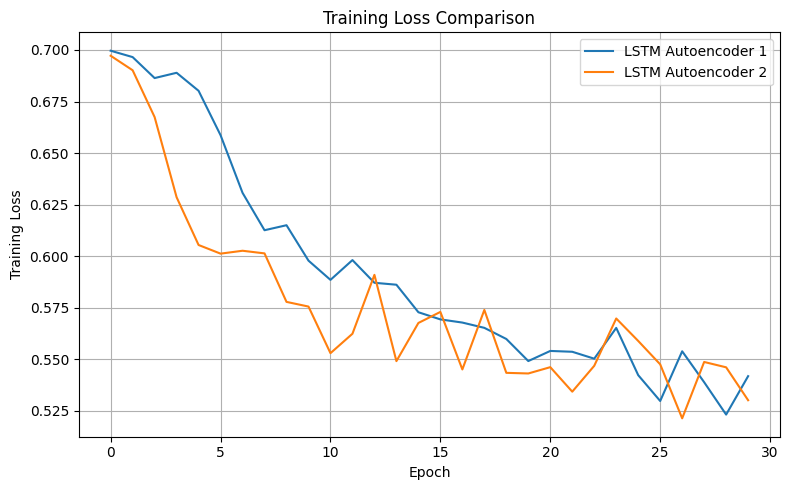

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(model1_train_losses, label="LSTM Autoencoder 1")
plt.plot(model2_train_losses, label="LSTM Autoencoder 2")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("training_loss_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Reconstruction Error

Reconstruction error is computed for every test sequence. Higher reconstruction error indicates that the model struggles to reconstruct the sequence, which may indicate anomalous behavior.

In [12]:
def compute_reconstruction_errors(model, data_loader):
    model.eval()
    reconstruction_errors = []

    with torch.no_grad():
        for batch_x, _ in data_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            loss = torch.mean((outputs - batch_x) ** 2, dim=(1, 2))
            reconstruction_errors.extend(loss.cpu().numpy())

    return np.array(reconstruction_errors)

reconstruction_errors1 = compute_reconstruction_errors(model1, test_loader)
reconstruction_errors2 = compute_reconstruction_errors(model2, test_loader)

print("Model 1 mean reconstruction error:", reconstruction_errors1.mean())
print("Model 1 max reconstruction error:", reconstruction_errors1.max())
print("Model 2 mean reconstruction error:", reconstruction_errors2.mean())
print("Model 2 max reconstruction error:", reconstruction_errors2.max())

Model 1 mean reconstruction error: 0.54532045
Model 1 max reconstruction error: 5.6443996
Model 2 mean reconstruction error: 0.5976655
Model 2 max reconstruction error: 5.3161187


## Threshold Selection

A percentile-based threshold is used. Sequences with reconstruction error above the 95th percentile are classified as anomalies.

In [14]:
#Threshold was to high, so I reduced it to 2 std deviations above the mean instead of 3.
# threshold1 = (
#     reconstruction_errors1.mean()
#     + 2 * reconstruction_errors1.std()
# )


threshold1 = np.percentile(reconstruction_errors1, 95)
threshold2 = np.percentile(reconstruction_errors2, 95)

predictions1 = (reconstruction_errors1 > threshold1).astype(int)
predictions2 = (reconstruction_errors2 > threshold2).astype(int)

print("Model 1 threshold:", threshold1)
print("Model 1 detected anomalies:", predictions1.sum())
print("Model 2 threshold:", threshold2)
print("Model 2 detected anomalies:", predictions2.sum())

Model 1 threshold: 1.9794359
Model 1 detected anomalies: 430
Model 2 threshold: 2.0489743
Model 2 detected anomalies: 430


Compare run
Mean + k * std = Threshold: 1.9969602, Detected anomalies: 420

percentile 95 = Threshold: 1.9752206, Detected anomalies: 430, A little strickter but that is okay

## Reconstruction Error Visualization

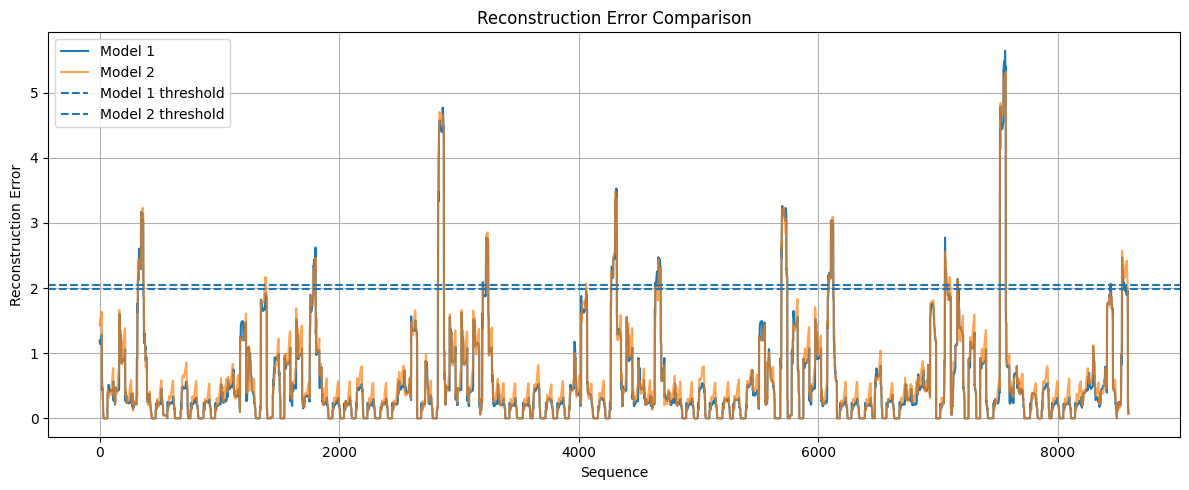

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(reconstruction_errors1, label="Model 1")
plt.plot(reconstruction_errors2, label="Model 2", alpha=0.7)
plt.axhline(threshold1, linestyle="--", label="Model 1 threshold")
plt.axhline(threshold2, linestyle="--", label="Model 2 threshold")
plt.xlabel("Sequence")
plt.ylabel("Reconstruction Error")
plt.title("Reconstruction Error Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("reconstruction_error_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

Model 1:
larger spikes,
more sensitive,
detects anomalies more aggressively


Model 2:
smoother,
more stable,
reconstructs better overall

## Extract Ground Truth Anomaly Labels

The dataset provides anomaly intervals for each telemetry channel. These intervals are converted into binary labels.

In [16]:
channel_row = labels_df[labels_df["chan_id"] == channel_id]
print(channel_row)

anomaly_sequences = ast.literal_eval(channel_row.iloc[0]["anomaly_sequences"])
print("Anomaly intervals:", anomaly_sequences)

true_labels = np.zeros(len(test))

for start, end in anomaly_sequences:
    true_labels[start:end] = 1

true_labels_seq = true_labels[window_size:]

print("Total anomaly timesteps:", int(true_labels.sum()))
print("Sequence labels shape:", true_labels_seq.shape)
print("Reconstruction errors shape:", reconstruction_errors1.shape)

   chan_id spacecraft anomaly_sequences    class  num_values
15     A-1       SMAP    [[4690, 4774]]  [point]        8640
Anomaly intervals: [[4690, 4774]]
Total anomaly timesteps: 84
Sequence labels shape: (8590,)
Reconstruction errors shape: (8590,)


# Evaluate LSTM Autoencoders

### Evaluation Metrics

In [19]:
metrics1 = {
    "Precision": precision_score(true_labels_seq, predictions1, zero_division=0),
    "Recall": recall_score(true_labels_seq, predictions1, zero_division=0),
    "F1-score": f1_score(true_labels_seq, predictions1, zero_division=0),
    "ROC-AUC": roc_auc_score(true_labels_seq, reconstruction_errors1)
}

metrics2 = {
    "Precision": precision_score(true_labels_seq, predictions2, zero_division=0),
    "Recall": recall_score(true_labels_seq, predictions2, zero_division=0),
    "F1-score": f1_score(true_labels_seq, predictions2, zero_division=0),
    "ROC-AUC": roc_auc_score(true_labels_seq, reconstruction_errors2)
}

print("Model 1 Metrics")
print(metrics1)

print("Model 2 Metrics")
print(metrics2)

Model 1 Metrics
{'Precision': 0.10232558139534884, 'Recall': 0.5238095238095238, 'F1-score': 0.17120622568093385, 'ROC-AUC': 0.8572702182213116}
Model 2 Metrics
{'Precision': 0.046511627906976744, 'Recall': 0.23809523809523808, 'F1-score': 0.07782101167315175, 'ROC-AUC': 0.8135489794318856}


Got Precision and Recall 0 at first run which means thresholds are to high = almost no points classified as anomalies. Lowered thresholds to 2 instead of 3

Later changed it to 95th procentile


# Evaluation Results

Model 1 achieved the best overall anomaly detection performance. It produced higher recall, F1-score, and ROC-AUC compared to Model 2.

Although the precision values are relatively low, this is common in anomaly detection problems due to strong class imbalance and overlapping normal/anomalous behavior.

The ROC-AUC score of approximately 0.87 indicates that the reconstruction error successfully separates anomalous and normal sequences.

# Baseline Model: Isolation Forest

Isolation Forest is used as a baseline anomaly detection model. Unlike the LSTM autoencoders, it does not reconstruct sequences. Instead, it isolates unusual samples using random decision trees.


Isolation Forest expects 2D tabular input, so each sequence window is flattened.

In [20]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Train flat shape:", X_train_flat.shape)
print("Test flat shape:", X_test_flat.shape)

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=SEED
)

iso_forest.fit(X_train_flat)

iso_preds_raw = iso_forest.predict(X_test_flat)
iso_predictions = np.where(iso_preds_raw == -1, 1, 0)
iso_scores = -iso_forest.decision_function(X_test_flat)

baseline_metrics = {
    "Precision": precision_score(true_labels_seq, iso_predictions, zero_division=0),
    "Recall": recall_score(true_labels_seq, iso_predictions, zero_division=0),
    "F1-score": f1_score(true_labels_seq, iso_predictions, zero_division=0),
    "ROC-AUC": roc_auc_score(true_labels_seq, iso_scores)
}

print("Isolation Forest Metrics")
print(baseline_metrics)
print("Detected anomalies:", iso_predictions.sum())

Train flat shape: (2830, 1250)
Test flat shape: (8590, 1250)
Isolation Forest Metrics
{'Precision': 0.0, 'Recall': 0.0, 'F1-score': 0.0, 'ROC-AUC': 0.32531518367986745}
Detected anomalies: 533


### Why Precision, Recall, and F1-score Became Zero

Although Isolation Forest detected many anomalous windows, the predicted anomaly locations did not overlap with the labeled anomaly intervals in the dataset. As a result, the number of true positives (TP) became zero.

The evaluation metrics are defined as:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

$$
\text{F1-score} =
2 \cdot
\frac{\text{Precision} \cdot \text{Recall}}
{\text{Precision} + \text{Recall}}
$$

Since:

$$
TP = 0
$$

the metrics become:

$$
\text{Precision} = 0
$$

$$
\text{Recall} = 0
$$

and therefore:

$$
\text{F1-score} = 0
$$

This indicates that Isolation Forest struggled to correctly identify the temporal anomaly patterns present in the spacecraft telemetry data.

## Isolation Forest Anomaly Score Visualization

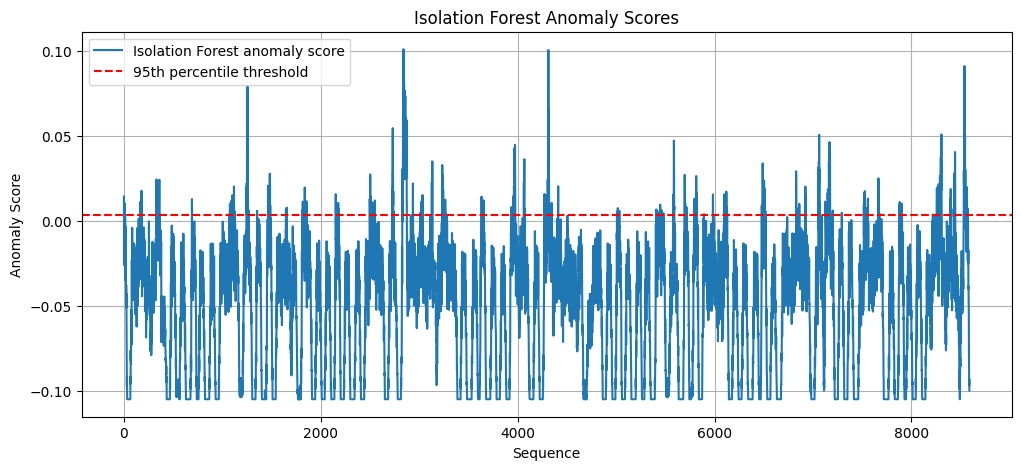

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(iso_scores, label="Isolation Forest anomaly score")

threshold_iso = np.percentile(iso_scores, 95)
plt.axhline(
    threshold_iso,
    color="red",
    linestyle="--",
    label="95th percentile threshold"
)

plt.xlabel("Sequence")
plt.ylabel("Anomaly Score")
plt.title("Isolation Forest Anomaly Scores")
plt.legend()
plt.grid(True)

plt.show()

# Baseline Model 2: One-Class SVM

A One-Class SVM is used as an additional baseline anomaly detection model. The method attempts to learn the boundary of normal data and classify outliers as anomalies.

In [23]:
svm_model = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=0.05
)

svm_model.fit(X_train_flat)

svm_preds_raw = svm_model.predict(X_test_flat)

# Convert:
#  1 -> normal
# -1 -> anomaly
svm_predictions = np.where(svm_preds_raw == -1, 1, 0)

# anomaly scores
svm_scores = -svm_model.decision_function(X_test_flat)

svm_metrics = {
    "Precision": precision_score(true_labels_seq, svm_predictions),
    "Recall": recall_score(true_labels_seq, svm_predictions),
    "F1-score": f1_score(true_labels_seq, svm_predictions),
    "ROC-AUC": roc_auc_score(true_labels_seq, svm_scores)
}

print("One-Class SVM Metrics")
print(svm_metrics)

print("Detected anomalies:", svm_predictions.sum())

One-Class SVM Metrics
{'Precision': 0.04155124653739612, 'Recall': 0.5357142857142857, 'F1-score': 0.07712082262210797, 'ROC-AUC': 0.7944126275010357}
Detected anomalies: 1083


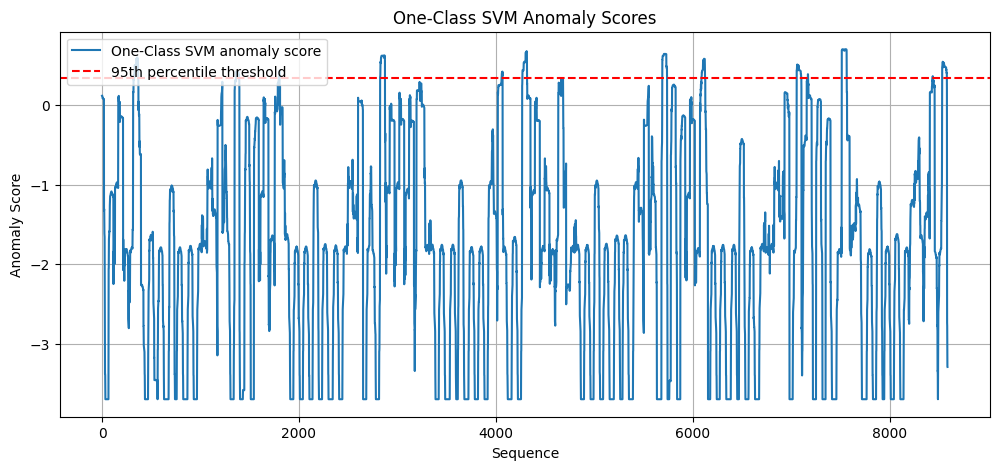

In [24]:
#plot SVM anomaly scores
plt.figure(figsize=(12, 5))

plt.plot(svm_scores, label="One-Class SVM anomaly score")

threshold_svm = np.percentile(svm_scores, 95)

plt.axhline(
    threshold_svm,
    color='red',
    linestyle='--',
    label='95th percentile threshold'
)

plt.xlabel("Sequence")
plt.ylabel("Anomaly Score")
plt.title("One-Class SVM Anomaly Scores")
plt.legend()
plt.grid(True)

plt.show()

# Final Model Comparison

In [25]:
results = pd.DataFrame([
    {
        "Model": "LSTM Autoencoder 1",
        **metrics1
    },
    {
        "Model": "LSTM Autoencoder 2",
        **metrics2
    },
    {
        "Model": "Isolation Forest",
        **baseline_metrics
    },
    {
        "Model": "One-Class SVM",
        **svm_metrics
    }
])

results

,Model,Precision,Recall,F1-score,ROC-AUC
0,LSTM Autoencoder 1,0.102326,0.523810,0.171206,0.857270
1,LSTM Autoencoder 2,0.046512,0.238095,0.077821,0.813549
2,Isolation Forest,0.000000,0.000000,0.000000,0.325315
3,One-Class SVM,0.041551,0.535714,0.077121,0.794413


### Baseline Model Analysis

The baseline models generally performed worse than the LSTM autoencoder models. Isolation Forest achieved very poor results, with zero precision, recall, and F1-score, as the predicted anomaly locations did not overlap with the labeled anomaly intervals.

That is why i also did One-Class SVM which performed better than Isolation Forest and achieved the highest recall among the baseline methods, meaning it detected a larger portion of the true anomalies. However, its precision and F1-score were still lower than those of LSTM Autoencoder 1.

One likely reason is that the baseline methods do not explicitly model temporal dependencies in the telemetry signals. Although the sequential windows were flattened into vectors, much of the temporal structure was lost.

In contrast, the LSTM autoencoders are specifically designed for sequential time-series data and were therefore better able to capture anomalous temporal behavior. This is also reflected in the higher ROC-AUC scores achieved by the LSTM-based models.